# 유저마다 효과가 다르다 — 이질적 처치 효과(HTE)

## 타노스 주니어의 고민

타노스의 아들 타노스 주니어는 아버지의 실패를 교훈 삼아 다음 우주 정복을 철저히 준비하고 있습니다.

아버지는 핑거스냅으로 우주 생명의 절반을 무작위로 제거했습니다. 결과는 다들 아시죠.

히어로들이 살아남았고, 결국 모든 게 원상복구됐습니다.

타노스 주니어는 생각했습니다.

> "무작위가 문제였어. 핑거스냅으로 절반을 없앴는데 하필 중요한 히어로들이 살아남은 거잖아. 이번엔 제거할 대상을 잘 골라야 해.  
> 스파이더맨을 없애야 할까, 아이언맨을 없애야 할까? 어떤 히어로를 없애야 범죄율이 가장 크게 오를까?"

히어로를 제거하는 것이 처치(treatment)라면, 그 효과는 어떤 히어로를 없애느냐에 따라 다를 수 있습니다.

타노스 주니어의 목표는 단순히 "처치가 효과 있는가?"가 아니라, "어떤 대상에게 처치했을 때 효과가 가장 큰가?"를 알아내는 것입니다.

### 🕸️ 스파이더맨이 사라지면 범죄율이 얼마나 오를까?

이 질문에 답하려면 같은 지구에서 두 가지 결과를 동시에 알아야 합니다.

| | 스파이더맨 생존 시 범죄율 | 스파이더맨 사망 시 범죄율 |
|--|--|--|
| 지구-616 | 관찰 가능 ✓ | 관찰 불가 ✗ |

스파이더맨이 살아있는 한, "없었다면 어떻게 됐을까?"는 영원히 알 수 없습니다.
이것이 인과추론의 근본 문제, 반사실(Counterfactual)입니다.

[잠재적 결과 프레임워크]

- $Y(0)$: 처치를 받지 않았을 때의 결과 (히어로 생존 시 범죄율)
- $Y(1)$: 처치를 받았을 때의 결과 (히어로 사망 시 범죄율)
- 우리가 관찰하는 건 $Y(0)$ 또는 $Y(1)$ 중 하나뿐

### 해결책: 여러 우주에서 비교하기

타노스 주니어의 해결책은 평행우주 데이터를 모으는 것입니다.
스파이더맨이 있는 우주들과 없는 우주들을 비교하면 평균적인 효과를 추정할 수 있습니다.

$$\text{ATE} = \mathbb{E}[Y(1) - Y(0)]$$

그런데 여기서 타노스 주니어는 중요한 걸 깨닫습니다.

> "잠깐, 스파이더맨과 아이언맨의 효과가 같을 리 없잖아. 그냥 '히어로 제거의 평균 효과'를 구해봤자 쓸모가 없어.  
> 나는 누구를 없애야 하는지 알아야 한다고."

히어로의 특성 $X$에 따라 처치 효과는 달라집니다.
개체의 특성에 따라 처치 효과가 달라지는 현상을 이질적 처치 효과(HTE)라고 합니다.

$$\text{CATE}(X) = \mathbb{E}[\, Y(1) - Y(0) \mid X \,]$$

- ATE는 전체 평균 효과 — 큰 그림은 보여주지만 타겟팅에는 쓸 수 없습니다.
- CATE는 특성 $X$를 가진 개체의 효과 — 누구에게 처치할지 결정할 수 있습니다.

## 🎮 게임에서의 이질적 처치 효과

어느 게임 회사가 6월 25일, 특정 처치를 시행했습니다.

> "이 처치가 유저 재방문에 영향을 줬을까?  
> 그리고 모든 유저에게 같은 효과가 나타났을까?"

처치 전후 각 7일간의 유저 행동 로그가 있습니다.

| 구분 | 기간 | 레이블(Y) |
|------|------|----------|
| T = 0 (처치 전) | 2022-06-18 ~ 06-25 | 이 기간 이후 재접속 여부 |
| T = 1 (처치 후) | 2022-06-25 ~ 07-02 | 이 기간 이후 재접속 여부 |

각 유저의 로그 파일에서 행동 특성을 뽑아내고, 재방문 여부(Y)와 연결합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BASE = Path('C:/Users/cutie/Documents/hte/backend-ts_v0.1/GAME_C_JUL')
CACHE = Path('C:/Users/cutie/Documents/hte/features_game_c_jul.parquet')

In [2]:
def extract_features(filepath):
    df = pd.read_parquet(filepath)
    if len(df) == 0:
        return None
    return {
        'n_logins': int((df['action'] == 1).sum()),
        'n_get': int((df['action'] == 2).sum()),
        'n_post': int((df['action'] == 3).sum()),
        'n_put': int((df['action'] == 4).sum()),
        'n_actions': len(df),
        'n_days': int(df['timestamp'].dt.date.nunique()),
    }

if CACHE.exists():
    data = pd.read_parquet(CACHE)
else:
    with open(BASE / 'info.json', encoding='utf-8') as f:
        info = json.load(f)
    records = []
    for item in info:
        fp = BASE / item['X']
        if not fp.exists():
            continue
        feats = extract_features(fp)
        if feats is None:
            continue
        feats.update({'T': item['T'], 'Y0': item['Y'][0], 'Y1': item['Y'][1], 'Y2': item['Y'][2]})
        records.append(feats)
    data = pd.DataFrame(records)
    data.to_parquet(CACHE, index=False)

## 1단계 — 평균 처치 효과(ATE): 전체적으로 보면?

처치 전과 후, 재방문율이 달라졌을까요?

$$\text{ATE} = \mathbb{E}[Y \mid T=1] - \mathbb{E}[Y \mid T=0]$$

- $T=0$: 처치 이전 기간의 유저들
- $T=1$: 처치 이후 기간의 유저들
- $Y$: 해당 기간이 끝난 후 게임에 다시 돌아왔는지 여부 (1 = 복귀, 0 = 미복귀)

In [4]:
rate_t0 = data.loc[data['T'] == 0, 'Y2'].mean()
rate_t1 = data.loc[data['T'] == 1, 'Y2'].mean()
ate = rate_t1 - rate_t0

print(f'처치 전 (T=0) 재방문율: {rate_t0:.1%}')
print(f'처치 후 (T=1) 재방문율: {rate_t1:.1%}')
print(f'ATE = {rate_t1:.1%} − {rate_t0:.1%} = {ate:+.1%}')

처치 전 (T=0) 재방문율: 55.7%
처치 후 (T=1) 재방문율: 57.9%
ATE = 57.9% − 55.7% = +2.2%


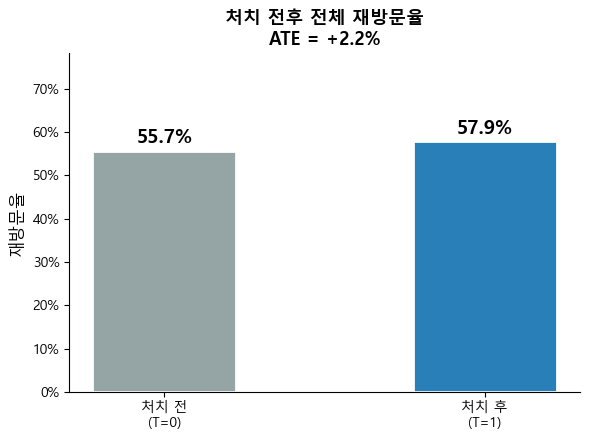

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    ['처치 전\n(T=0)', '처치 후\n(T=1)'],
    [rate_t0, rate_t1],
    color=['#95a5a6', '#2980b9'],
    width=0.45, edgecolor='white', linewidth=2
)

for bar, val in zip(bars, [rate_t0, rate_t1]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f'{val:.1%}',
        ha='center', va='bottom', fontsize=14, fontweight='bold'
    )

ax.set_ylim(0, max(rate_t0, rate_t1) * 1.35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('재방문율', fontsize=12)
ax.set_title(f'처치 전후 전체 재방문율\nATE = {ate:+.1%}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

처치 후 재방문율이 소폭 상승했습니다.

## 2단계 — 그런데, 정말 모든 유저한테 같은 효과였을까요?

ATE는 전체 평균입니다. 하지만 게임 유저들은 각자 다릅니다.

- 7일 동안 수십 번 접속하는 코어 유저
- 몇 번만 접속하는 라이트 유저

이 두 그룹이 처치에 같은 방식으로 반응했을까요?

각 유저의 처치 전 접속 횟수(`n_logins`)를 기준으로 나눠서 확인해봅시다.

In [6]:
median_logins = data['n_logins'].median()
data['user_type'] = np.where(
    data['n_logins'] > median_logins,
    '코어 유저\n(접속 횟수 많음)',
    '라이트 유저\n(접속 횟수 적음)'
)

group_stats = (
    data.groupby(['user_type', 'T'])['Y2']
    .mean()
    .unstack()
    .rename(columns={0: '재방문율 (T=0)', 1: '재방문율 (T=1)'})
)
group_stats['처치 효과'] = group_stats['재방문율 (T=1)'] - group_stats['재방문율 (T=0)']

print(f'접속 횟수 중앙값: {median_logins:.0f}회')
display(
    group_stats.style
    .format('{:.1%}')
    .bar(subset=['처치 효과'], align='zero', color=['#e74c3c', '#27ae60'])
)

접속 횟수 중앙값: 14회


T,재방문율 (T=0),재방문율 (T=1),처치 효과
user_type,,,
라이트 유저 (접속 횟수 적음),18.4%,26.4%,8.0%
코어 유저 (접속 횟수 많음),90.9%,92.2%,1.3%


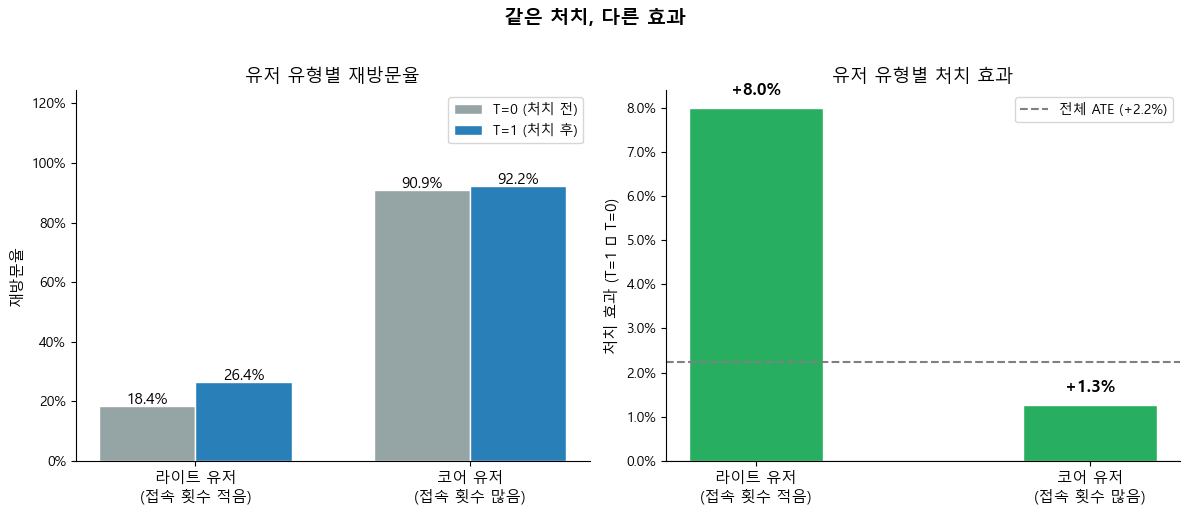

In [7]:
groups = group_stats.index.tolist()
rates_before = group_stats['재방문율 (T=0)'].tolist()
rates_after = group_stats['재방문율 (T=1)'].tolist()
cates_group = group_stats['처치 효과'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 유저 유형별 재방문율
x = np.arange(len(groups))
w = 0.35
b1 = ax1.bar(x - w/2, rates_before, w, label='T=0 (처치 전)', color='#95a5a6', edgecolor='white')
b2 = ax1.bar(x + w/2, rates_after, w, label='T=1 (처치 후)', color='#2980b9', edgecolor='white')

for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{bar.get_height():.1%}', ha='center', fontsize=11)

ax1.set_xticks(x)
ax1.set_xticklabels(groups, fontsize=11)
ax1.set_ylim(0, max(rates_before + rates_after) * 1.35)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylabel('재방문율', fontsize=11)
ax1.set_title('유저 유형별 재방문율', fontsize=13)
ax1.legend(fontsize=10)

# 유저 유형별 처치 효과
colors_cate = ['#27ae60' if c > 0 else '#e74c3c' for c in cates_group]
b3 = ax2.bar(groups, cates_group, color=colors_cate, width=0.4, edgecolor='white')

for bar, val in zip(b3, cates_group):
    offset = 0.003 if val >= 0 else -0.007
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
             f'{val:+.1%}', ha='center', fontsize=12, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(ate, color='gray', linestyle='--', linewidth=1.5, label=f'전체 ATE ({ate:+.1%})')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('처치 효과 (T=1 − T=0)', fontsize=11)
ax2.set_title('유저 유형별 처치 효과', fontsize=13)
ax2.legend(fontsize=10)
ax2.set_xticklabels(groups, fontsize=11)

plt.suptitle('같은 처치, 다른 효과', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3단계 — CATE: 연속적으로 추정하기

두 그룹으로 나누는 것에서 한 발 더 나아가봅시다.
접속 횟수가 1회, 5회, 10회... 로 늘어날수록 처치 효과는 어떻게 변할까요?

이를 추정하는 가장 직관적인 방법은 상호작용항을 포함한 회귀 모델입니다.

$$Y = \beta_0 + \beta_1 T + \beta_2 X + \beta_3 (T \times X) + \varepsilon$$

이 식을 $T$로 미분하면 특성 $X$를 가진 유저의 처치 효과가 됩니다.

$$\text{CATE}(X) = \frac{\partial \hat{Y}}{\partial T} = \beta_1 + \beta_3 \cdot X$$

- $\beta_3 > 0$: $X$가 클수록 처치 효과가 커짐
- $\beta_3 < 0$: $X$가 클수록 처치 효과가 작아짐
- $\beta_3 \approx 0$: 처치 효과가 $X$와 무관

In [10]:
from numpy.linalg import lstsq

X_var = 'n_logins'

model_data = data[['T', X_var, 'Y2']].dropna().copy()
model_data['T_x_X'] = model_data['T'] * model_data[X_var]

X_mat = np.column_stack([
    np.ones(len(model_data)),
    model_data['T'],
    model_data[X_var],
    model_data['T_x_X']
])
y_vec = model_data['Y2'].values

coef, _, _, _ = lstsq(X_mat, y_vec, rcond=None)
beta0, beta_T, beta_X, beta_TX = coef

print(f'Y = β₀ + β₁·T + β₂·n_logins + β₃·(T × n_logins)')
print(f'β₁ (T 기본 효과): {beta_T:+.4f}')
print(f'β₃ (T × n_logins 상호작용): {beta_TX:+.6f}')
print()

p5 = int(model_data[X_var].quantile(0.05))
p50 = int(model_data[X_var].median())
p95 = int(model_data[X_var].quantile(0.95))
print(f'접속 {p5}회 유저 (하위 5%): {beta_T + beta_TX*p5:+.1%}')
print(f'접속 {p50}회 유저 (중앙값): {beta_T + beta_TX*p50:+.1%}')
print(f'접속 {p95}회 유저 (상위 5%): {beta_T + beta_TX*p95:+.1%}')

model_data['cate'] = beta_T + beta_TX * model_data[X_var]

Y = β₀ + β₁·T + β₂·n_logins + β₃·(T × n_logins)
β₁ (T 기본 효과): +0.1679
β₃ (T × n_logins 상호작용): -0.009004

접속 1회 유저 (하위 5%): +15.9%
접속 14회 유저 (중앙값): +4.2%
접속 31회 유저 (상위 5%): -11.1%


β₃ = -0.009라는 것은, 접속 횟수가 1회 늘어날 때마다 처치 효과가 약 0.9%p씩 줄어든다는 의미입니다.

직관적으로도 이해가 됩니다. 코어 유저는 처치가 없어도 어차피 돌아옵니다. 처치가 결과를 바꾸지 못하니 처치 효과가 작습니다. 반면 라이트 유저는 처치가 없으면 돌아올 계기가 없는데, 처치가 그 역할을 합니다.

왼쪽 그래프는 이 관계를 선으로 표현한 것입니다. 오른쪽 그래프는 실제 유저 2,500여 명에게 이 공식을 적용했을 때 각자의 예상 CATE가 어떻게 분포하는지를 보여줍니다.

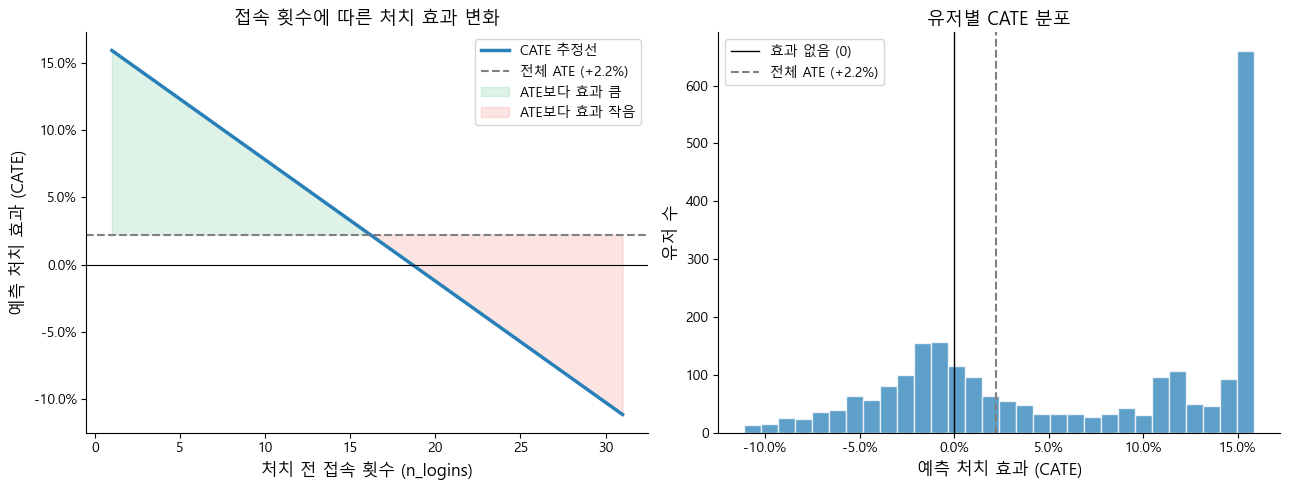

ATE보다 효과 큰 유저:  1,382명 (54.4%)
ATE보다 효과 작은 유저: 1,157명 (45.6%)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x_max = int(model_data[X_var].quantile(0.95))
x_min = max(1, int(model_data[X_var].quantile(0.05)))
login_range = np.linspace(x_min, x_max, 300)
cate_line = beta_T + beta_TX * login_range

# 접속 횟수에 따른 CATE 변화
ax1.plot(login_range, cate_line, color='#2980b9', linewidth=2.5, label='CATE 추정선')
ax1.axhline(ate, color='gray', linestyle='--', linewidth=1.5, label=f'전체 ATE ({ate:+.1%})')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.fill_between(login_range, cate_line, ate,
                 where=(cate_line > ate), alpha=0.15, color='#27ae60', label='ATE보다 효과 큼')
ax1.fill_between(login_range, cate_line, ate,
                 where=(cate_line <= ate), alpha=0.15, color='#e74c3c', label='ATE보다 효과 작음')
ax1.set_xlabel('처치 전 접속 횟수 (n_logins)', fontsize=12)
ax1.set_ylabel('예측 처치 효과 (CATE)', fontsize=12)
ax1.set_title('접속 횟수에 따른 처치 효과 변화', fontsize=13)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.legend(fontsize=10)

# CATE 분포 (상위 5% 제외)
plot_data = model_data[model_data[X_var] <= x_max]
ax2.hist(plot_data['cate'], bins=30, color='#2980b9', alpha=0.75, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1, linestyle='-', label='효과 없음 (0)')
ax2.axvline(ate, color='gray', linewidth=1.5, linestyle='--', label=f'전체 ATE ({ate:+.1%})')
ax2.set_xlabel('예측 처치 효과 (CATE)', fontsize=12)
ax2.set_ylabel('유저 수', fontsize=12)
ax2.set_title('유저별 CATE 분포', fontsize=13)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

above_ate = (model_data['cate'] > ate).sum()
below_ate = (model_data['cate'] <= ate).sum()
print(f'ATE보다 효과 큰 유저: {above_ate:,}명 ({above_ate/len(model_data):.1%})')
print(f'ATE보다 효과 작은 유저: {below_ate:,}명 ({below_ate/len(model_data):.1%})')

CATE 분포를 보면 유저들이 ATE(+2.2%) 주변에 몰려 있지 않고, 넓게 퍼져 있습니다. 이 분포가 바로 HTE의 시각적 증거입니다.

만약 ATE만 봤다면 "이 처치는 +2.2% 효과가 있다"고 결론 내렸을 겁니다. 하지만 실제로는 라이트 유저에게는 +15%대의 큰 효과가, 코어 유저에게는 오히려 음의 효과가 나타납니다. 평균이 이질성을 숨기고 있었던 것입니다.

## 정리

| 개념 | 수식 | 의미 |
|------|------|------|
| ATE | $\mathbb{E}[Y(1) - Y(0)]$ | 모든 유저에 대한 평균 처치 효과 |
| CATE | $\mathbb{E}[Y(1) - Y(0) \mid X]$ | 특성 $X$를 가진 유저의 처치 효과 |
| HTE | CATE가 유저마다 다름 | 평균이 숨기는 이질성을 드러냄 |